In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Entregavel 3 - análises com o modelo boruta selecionado

In [ ]:
#instalação das bibliotecas não nativas no Colab
!pip install shap
!pip install xgboost==3.0.0

In [ ]:
# Abrindo banco de dados

In [ ]:
#Definindo semente

In [ ]:
def set_seed(seed=42):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)

    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass


Instalando pacotes

In [ ]:
!pip install dfply
!pip install scikit-plot
!pip install graphviz
!pip install dtreeviz
!pip install catboost
!pip install shap
#!pip install xgboost
!pip install lightgbm
!pip install boruta
!pip install tabpfn
!pip install imbalanced-learn
!pip install pycalib

In [ ]:
#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from xgboost import XGBClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

#importancia das variaveis
import shap

#definição de seed para reprodutibilidade
seed = 42

In [ ]:
#Definindo semente

In [ ]:
def set_seed(seed=42):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)

    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass


In [ ]:
#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from xgboost import XGBClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

#importancia das variaveis
import shap

#definição de seed para reprodutibilidade
seed = 42

In [ ]:
# Carregando pacotes

In [ ]:
import pandas as pd  # processamento de bancos de dados
import numpy as np  # processamento numérico
import matplotlib.pyplot as plt  # geração de gráficos
import seaborn as sns  # geração de gráficos alternativos

#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from tabpfn import TabPFNClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, FixedThresholdClassifier
from sklearn.metrics import roc_curve, precision_recall_curve, auc, classification_report, confusion_matrix
from sklearn.calibration import calibration_curve

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração de gráficos no notebook
%matplotlib inline
plt.rcParams["figure.figsize"] = [10, 5]
plt.style.use("fivethirtyeight")
%config InlineBackend.figure_format = 'retina'

# Configurações de fonte e matemática
from matplotlib import rc
rc('font', **{'family': 'sans-serif', 'sans-serif': ['DejaVu Sans'], 'size': 10})
rc('mathtext', **{'default': 'regular'})

#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from xgboost import XGBClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

#seleção das variáveis
from boruta import BorutaPy

#importancia das variaveis
import shap

# SCIKIT-LEARN

#bibliotecas do sklearn para preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import (roc_curve, auc, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             accuracy_score, brier_score_loss)
from sklearn.model_selection import (KFold, cross_val_score, train_test_split,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

from sklearn import preprocessing
from tabpfn import TabPFNClassifier

import shap

# Biblioteca dfply
from dfply import *

# Visualização de árvores de decisão
from dtreeviz.trees import *

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

from collections import Counter

# Ignorar warnings
import warnings
warnings.filterwarnings("ignore")

# Definição de semente de aleatoriedade
np.random.seed(42)

#definição de seed para reprodutibilidade
seed = 42

In [76]:
import pandas as pd

In [77]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML_2026/dados_treino_processados2boruta_ap_2015_2024.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML_2026/dados_teste_processados2boruta_ap_2015_2024.csv",
                        encoding='latin1', sep=",")

In [78]:
# Visualização da base de treino
df_train

,agravalcoo_0.0,tratsup_at_9.0,tratsup_at_1.0,agravtabac_0.0,agravdroga_0.0,cs_sexo_1,agravalcoo_1.0,agravtabac_1.0,tratsup_at_0.0,contato_maior5_0.0,...,faixa_etaria2_1.0,escola_faixa_0.0,bacilosc_e_1.0,raiox_tora_1.0,escola_faixa_9.0,pop_rua_0.0,bacilosc_e_9.0,faixa_etaria2_2.0,pop,cura
0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.572567,1
1,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.572567,1
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.572567,1
3,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.572567,1
4,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,...,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,-1.431558,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.572567,0
784,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.572567,1
785,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.572567,1
786,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,-2.027300,1


In [79]:
# Visualização da base de teste
df_test

,agravalcoo_0.0,tratsup_at_9.0,tratsup_at_1.0,agravtabac_0.0,agravdroga_0.0,cs_sexo_1,agravalcoo_1.0,agravtabac_1.0,tratsup_at_0.0,contato_maior5_0.0,...,faixa_etaria2_1.0,escola_faixa_0.0,bacilosc_e_1.0,raiox_tora_1.0,escola_faixa_9.0,pop_rua_0.0,bacilosc_e_9.0,faixa_etaria2_2.0,pop,cura
0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,-1.943738,0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.572567,0
2,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.572567,1
3,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.572567,1
4,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.572567,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,...,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.572567,0
351,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.572567,1
352,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.572567,1
353,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,-2.041310,1


In [80]:
# Visualização da base de treino
df_train

,agravalcoo_0.0,tratsup_at_9.0,tratsup_at_1.0,agravtabac_0.0,agravdroga_0.0,cs_sexo_1,agravalcoo_1.0,agravtabac_1.0,tratsup_at_0.0,contato_maior5_0.0,...,faixa_etaria2_1.0,escola_faixa_0.0,bacilosc_e_1.0,raiox_tora_1.0,escola_faixa_9.0,pop_rua_0.0,bacilosc_e_9.0,faixa_etaria2_2.0,pop,cura
0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.572567,1
1,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.572567,1
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.572567,1
3,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.572567,1
4,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,...,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,-1.431558,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.572567,0
784,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.572567,1
785,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.572567,1
786,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,-2.027300,1


In [81]:
# Visualização da base de teste
df_test

,agravalcoo_0.0,tratsup_at_9.0,tratsup_at_1.0,agravtabac_0.0,agravdroga_0.0,cs_sexo_1,agravalcoo_1.0,agravtabac_1.0,tratsup_at_0.0,contato_maior5_0.0,...,faixa_etaria2_1.0,escola_faixa_0.0,bacilosc_e_1.0,raiox_tora_1.0,escola_faixa_9.0,pop_rua_0.0,bacilosc_e_9.0,faixa_etaria2_2.0,pop,cura
0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,-1.943738,0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.572567,0
2,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.572567,1
3,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.572567,1
4,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.572567,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,...,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.572567,0
351,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.572567,1
352,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.572567,1
353,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,-2.041310,1


In [82]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

In [83]:
import joblib
from sklearn.metrics import roc_auc_score

# Load the best RandomForest model to ensure it's available for AUC calculation.
# Note: In the preceding cell (l2315e76mMlq), the model was incorrectly assigned
# to the variable `best_method_rf`. We'll load it into a dedicated model variable here.
rf_novo = joblib.load('modelo_rf_boruta_ap_2015_2024.pkl')

# Mostrar hiperparâmetros
print(rf_novo.get_params())


{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': np.int64(14), 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': np.float64(0.05), 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': np.int64(500), 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


Metricas no threshold padrao

In [84]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

# Generate predictions and probabilities
# Align X_test_novo with the features the model was trained on.
# The model 'rf_novo' was loaded from a .pkl file and expects a specific set of features (likely from Boruta selection).
# We retrieve the feature names from the model itself and filter X_test_novo accordingly.
try:
    # Get the feature names the model was trained on.
    # This attribute is available for scikit-learn models after fitting.
    model_expected_features = rf_novo.feature_names_in_

    # Filter X_test_novo to include only these features and ensure their order matches.
    # This will drop any columns in X_test_novo that the model was not trained on,
    # and reorder existing columns to match the model's expectation.
    X_test_aligned = X_test_novo[model_expected_features]
except AttributeError:
    # Fallback if 'feature_names_in_' is not available (e.g., older scikit-learn version or custom model).
    # In such cases, we proceed with X_test_novo as is, hoping the problem was not feature name mismatch.
    print("Warning: 'rf_novo.feature_names_in_' attribute not found. Proceeding with original X_test_novo.")
    X_test_aligned = X_test_novo

y_pred_rf = rf_novo.predict(X_test_aligned)
y_prob_rf = rf_novo.predict_proba(X_test_aligned)[:, 1]

# Métricas
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

# Especificidade
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
specificity_rf = tn / (tn + fp) if (tn + fp) > 0 else 0.0
npv_rf = tn / (tn + fn) if (tn + fn) > 0 else 0.0

# Impressão
print(f'RF - Accuracy: {accuracy_rf:.4f}')
print(f'RF - Recall (Sensibilidade): {recall_rf:.4f}')
print(f'RF - Specificity (Especificidade): {specificity_rf:.4f}')
print(f'RF - Negative Predictive Value (NPV): {npv_rf:.4f}')
print(f'RF - Precision: {precision_rf:.4f}')
print(f'RF - F1 Score: {f1_rf:.4f}')
print(f'RF - ROC AUC: {roc_auc_rf:.4f}')
print(f'RF - PR AUC: {pr_auc_rf:.4f}')

RF - Accuracy: 0.8394
RF - Recall (Sensibilidade): 1.0000
RF - Specificity (Especificidade): 0.0000
RF - Negative Predictive Value (NPV): 0.0000
RF - Precision: 0.8394
RF - F1 Score: 0.9127
RF - ROC AUC: 0.7143
RF - PR AUC: 0.9133


→ O threshold padrão do predict dos modelos é 0.5, mas podemos ajustá-lo para balancear sensibilidade e precisão, dependendo do que queremos otimizar

##• Avaliação do modelo final com matriz de confusão e mudança do threshold (Obrigatório)

## Classification Report e Matriz de Confusão - threshold

In [64]:
df = pd.read_csv("dadosAP_entregavel_1_2015_2024.csv",sep=",")

In [65]:
df['cura'].value_counts(normalize=True , dropna=False)

,proportion
cura,
1,0.857393
0,0.142607


In [85]:
#Cria uma copia do cat, para não sobescrevê-lo
rf_novo_th = deepcopy(rf_novo)

#Criação do novo modelo
rf_novo_th = FixedThresholdClassifier(rf_novo_th, threshold=0.857393, response_method='predict_proba').fit(X_train_novo, y_train)


In [86]:
#obtenção da predição
y_pred_rf_novo_th = rf_novo_th.predict(X_test_novo)

#criação do classification report
print(classification_report(y_test, y_pred_rf_novo_th,
      target_names=['Não cura', 'Cura']))

              precision    recall  f1-score   support

    Não cura       0.30      0.61      0.40        57
        Cura       0.91      0.73      0.81       298

    accuracy                           0.71       355
   macro avg       0.60      0.67      0.61       355
weighted avg       0.81      0.71      0.74       355



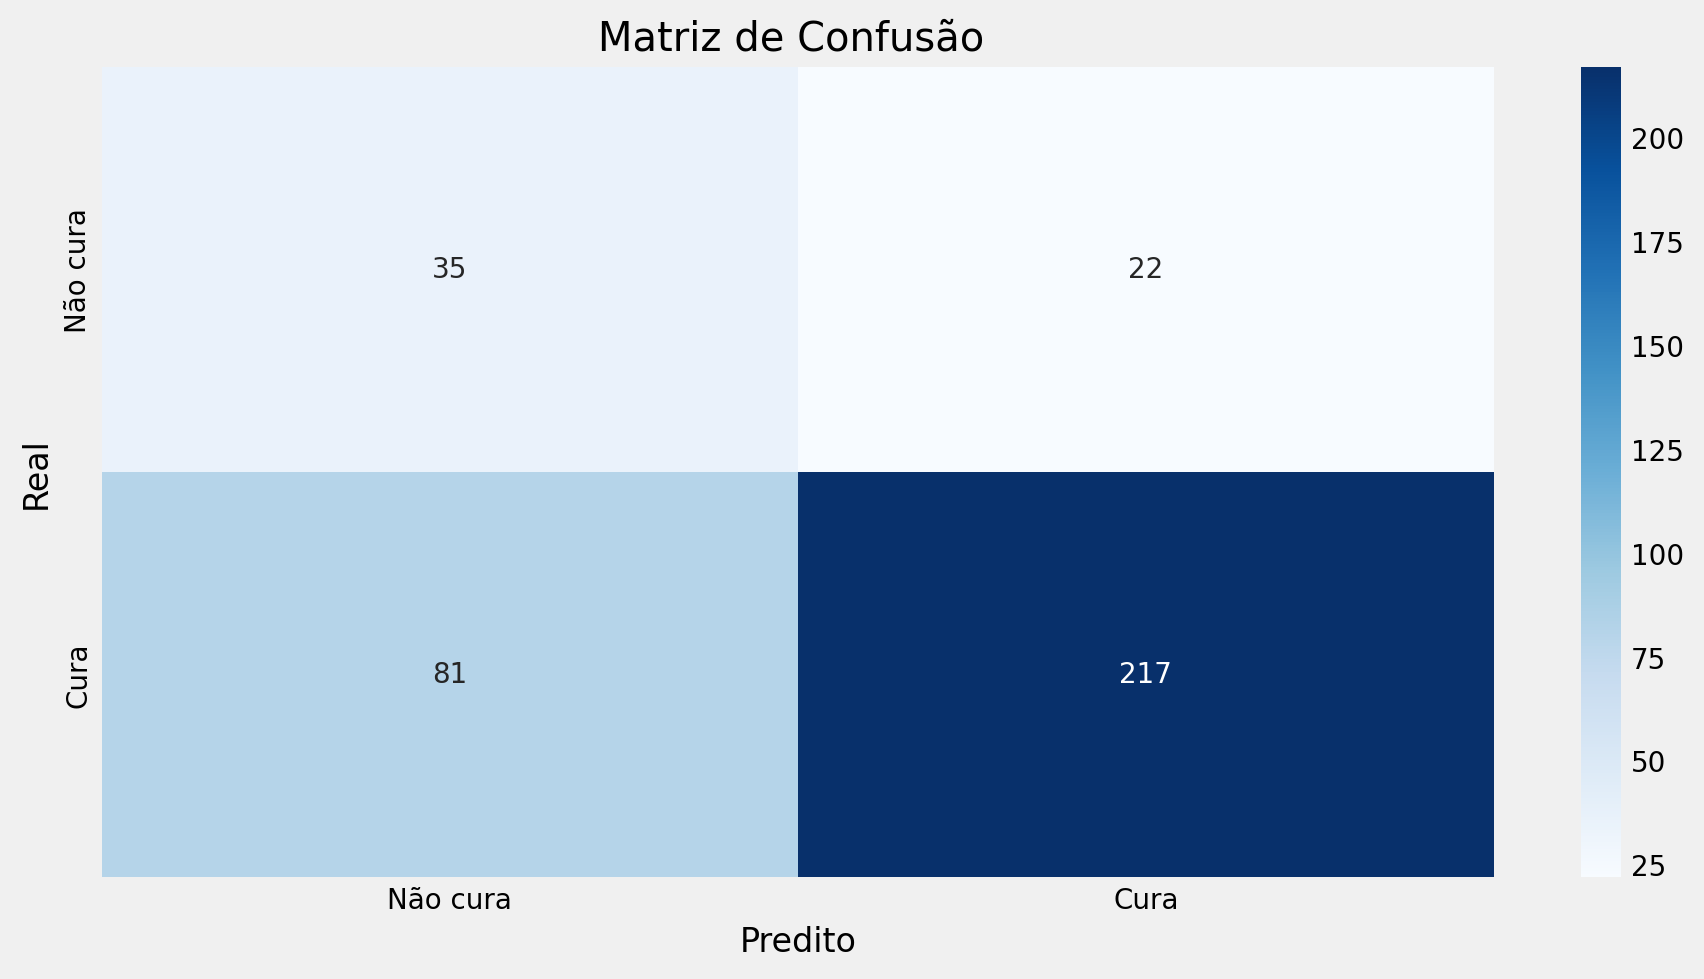

In [87]:
#cria e plota a matriz de confusão
cm =confusion_matrix(y_test, y_pred_rf_novo_th)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Não cura', 'Cura'], yticklabels=['Não cura', 'Cura'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão ')
plt.show()

### Metricas threshold

In [88]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

# Probabilidades
y_prob_rf = rf_novo.predict_proba(X_test_novo)[:, 1]

# Aplica o threshold
threshold = 0.857393
y_pred_rf_novo_th = (y_prob_rf >= threshold).astype(int)

# Métricas
accuracy_rf = accuracy_score(y_test, y_pred_rf_novo_th)
precision_rf = precision_score(y_test, y_pred_rf_novo_th)
recall_rf = recall_score(y_test, y_pred_rf_novo_th)
f1_rf = f1_score(y_test, y_pred_rf_novo_th)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)  # AUC usa probabilidade
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

# Especificidade e NPV
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf_novo_th).ravel()
specificity_rf = tn / (tn + fp)
npv_rf = tn / (tn + fn) if (tn + fn) > 0 else 0.0

# Impressão
print(f'RF - Threshold usado: {threshold}')
print(f'RF - Accuracy: {accuracy_rf:.4f}')
print(f'RF - Recall (Sensibilidade): {recall_rf:.4f}')
print(f'RF - Specificity (Especificidade): {specificity_rf:.4f}')
print(f'RF - Negative Predictive Value (NPV): {npv_rf:.4f}')
print(f'RF - Precision: {precision_rf:.4f}')
print(f'RF - F1 Score: {f1_rf:.4f}')
print(f'RF - ROC AUC: {roc_auc_rf:.4f}')
print(f'RF - PR AUC: {pr_auc_rf:.4f}')


RF - Threshold usado: 0.857393
RF - Accuracy: 0.7099
RF - Recall (Sensibilidade): 0.7282
RF - Specificity (Especificidade): 0.6140
RF - Negative Predictive Value (NPV): 0.3017
RF - Precision: 0.9079
RF - F1 Score: 0.8082
RF - ROC AUC: 0.7143
RF - PR AUC: 0.9133


##• Avaliação do modelo final com distribuições por classe

## Distribuição de Probabilidade do Desfecho
→ Verificar a distribuição das probabilidades previstas pelo modelo é fundamental para entender como ele diferencia as classes.

→ Essa análise auxilia na escolha de um threshold adequado, impactando diretamente a matriz de confusão e métricas derivadas dela. Ao observar como as probabilidades se concentram ou se sobrepõem entre as classes, é possível ajustar o ponto de corte, alinhando a performance do modelo aos objetivos do problema.

In [70]:
# Exemplo com o melhor modelo
df_pred = pd.DataFrame({
    "probabilidade": y_prob_rf,
    "classe_real": y_test
})

In [71]:
df_pred

,probabilidade,classe_real
0,0.766325,0
1,0.620193,0
2,0.868021,1
3,0.826314,1
4,0.953570,1
...,...,...
350,0.896494,0
351,0.843900,1
352,0.941891,1
353,0.949743,1


In [72]:
#Criação da Figura de Histograma
fig = px.histogram(
    df_pred,
    x="probabilidade",
    color="classe_real",
    nbins=50,
    barmode="overlay",
    histnorm="percent",  # normaliza para comparar porcentagens
    color_discrete_map={0: "blue", 1: "red"}
)

fig.update_layout(
    title="Distribuição das Probabilidades Previstas",
    xaxis_title="Probabilidade Prevista de Cura",
    yaxis_title="Porcentagem de Observações",
    legend_title="Classe Real",
    width=900,
    height=500
)

fig.show()

#5- Feature Importance do Modelo Final

---



#Importancia das variaveis

→ O SHAP (SHapley Additive exPlanations) é uma técnica de interpretabilidade que atribui a cada variável uma contribuição para a previsão de um modelo, inspirado na teoria dos jogos de Shapley.

→ O SHAP consegue explicar tanto previsões individuais (por exemplo, por que um paciente foi classificado como de alto risco), quanto a importância global das variáveis, permitindo entender quais fatores mais influenciam o modelo.

→ Pode ser utilizado para qualquer modelo, mas para cada tipo de modelo (e.g., árvores/boosting, lineares, redes neurais), é necessário utilizar alguns comandos específicos, como TreeExplainer, LinearExplainer ou KernelExplainer.

→  Documentação: https://shap.readthedocs.io/en/latest/index.html

Obtenção do SHAP Values

In [89]:
import shap

In [90]:
from os.path import expanduser
# Criação do Explainer (para árvores)
explainer = shap.TreeExplainer(rf_novo)

# Criação dos SHAP Values
shap_values = explainer(X_test_novo)

# Computa o SHAP values para a base de teste


##• Importância das variáveis com SHAP — geral e individual (Obrigatório)

In [91]:
shap_values

.values =
array([[[ 0.04501501, -0.04501501],
        [-0.01426104,  0.01426104],
        [ 0.02434307, -0.02434307],
        ...,
        [ 0.00083543, -0.00083543],
        [ 0.00110628, -0.00110628],
        [ 0.01036413, -0.01036413]],

       [[ 0.05095853, -0.05095853],
        [ 0.07537651, -0.07537651],
        [ 0.03430832, -0.03430832],
        ...,
        [-0.0010531 ,  0.0010531 ],
        [ 0.00070774, -0.00070774],
        [ 0.0034128 , -0.0034128 ]],

       [[-0.00856105,  0.00856105],
        [-0.01945344,  0.01945344],
        [ 0.02330767, -0.02330767],
        ...,
        [ 0.00310039, -0.00310039],
        [ 0.00239022, -0.00239022],
        [-0.00173757,  0.00173757]],

       ...,

       [[-0.00925567,  0.00925567],
        [-0.01778678,  0.01778678],
        [ 0.01643567, -0.01643567],
        ...,
        [-0.00025627,  0.00025627],
        [ 0.00127759, -0.00127759],
        [-0.00424023,  0.00424023]],

       [[-0.00760724,  0.00760724],
        [-0.01410

→ Após o cálculo do SHAP Values, podemos transformar os valores obtidos nas importâncias das variáveis

## Importância Global das Variáveis

In [92]:
!pip install -U kaleido


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.5 MB/s eta 0:00:00


In [93]:
# Dicionário com os nomes antigos e os novos nomes
colunas_renomeadas = {
    'bacilosc_e_9.0': 'unknown_1st_bacilloscopy',
    'bacilosc_2_9.0': 'unknown_2nd_bacilloscopy',
    'bacilosc_4_9.0': 'unknown_4th_bacilloscopy',
    'bacilosc_2_0.0': 'negative_2nd_bacilloscopy',
    'bacilosc_4_0.0': 'negative_4th_bacilloscopy',
    'bacilosc_e_0.0': 'negative_baseline_bacilloscopy',
    'bacilosc_4_1.0': 'positive_4th_bacilloscopy',
    'cultura_es_0.0': 'negative_sputum_culture',
    'cultura_es_1.0': 'positive_sputum_culture',
    'cultura_es_9.0': 'unknown_sputum_culture',
    'cs_sexo_1': 'male',
    'escola_faixa_1.0': 'study-years_>5',
    'escola_faixa_9.0': 'unknown_study-years',
    'faixa_etaria2_0.0': '0-19 yo',
    'faixa_etaria2_1.0': '20-39 yo',
    'faixa_etaria2_2.0': '40-59 yo',
    'faixa_etaria2_3.0': '60+ yo',
    'faixa_etaria2_9.0': 'unknown_age',
    'agravdroga_1.0': 'drug_user',
    'agravdroga_0.0': 'no_drug_user',
    'agravdroga_9.0': 'unknown_drug_user',
    'agravalcoo_1.0': 'alcohol_user',
    'agravalcoo_0.0': 'no_alcohol_user',
    'agravalcoo_9.0': 'unknown_alcohol_user',
    'cs_raca_1.0': 'white',
    'cs_raca_2.0': 'black',
    'tratsup_at_1.0': 'treatment_support',
    'tratsup_at_0.0': 'no_treatment_support',
    'tratsup_at_9.0': 'unknown_treatment_support',
    'pop_rua_1.0': 'homeless',
    'pop_liber_1.0': 'incarcerated',
    'pop': 'population',
    'agravdiabe_1.0': 'diabetes',
    'agravdiabe_0.0': 'no_diabetes',
    'agravdoenca_1.0': 'other_diseases',
    'agravtabac_1.0': 'smoking',
    'agravtabac_0.0': 'no_smoking',
    'agravdoenca_0.0': 'no_other_diseases',
    'agravtabac_9.0': 'unknown_smoking',
    'agravdoenc_1.0':'other_diseases',
    'agravdoenc_0.0': 'no_other_diseases',
    'agravdoenc_9.0': 'unknown_other_diseases',
    'agravdiabe_9.0': 'unknown_diabetes',
    'raiox_tora_1.0': 'suggestive_chest_X-ray',
    'raiox__tora_0.0': 'normal_chest_X-ray',
    'raiox_tora_9.0': 'unknown_chest_X-ray',
    'tempo_diag_trat_14_0.0': 'no_delay_treatment',
    'tempo_diag_trat_14_1.0': 'delay_treatment',
    'benef_gov_0.0': 'no_financial_support',
    'benef_gov_1.0': 'financial_support'
}

Gráfico salvo como 'shap_bar_plot.tiff' (Matplotlib, 300 DPI)


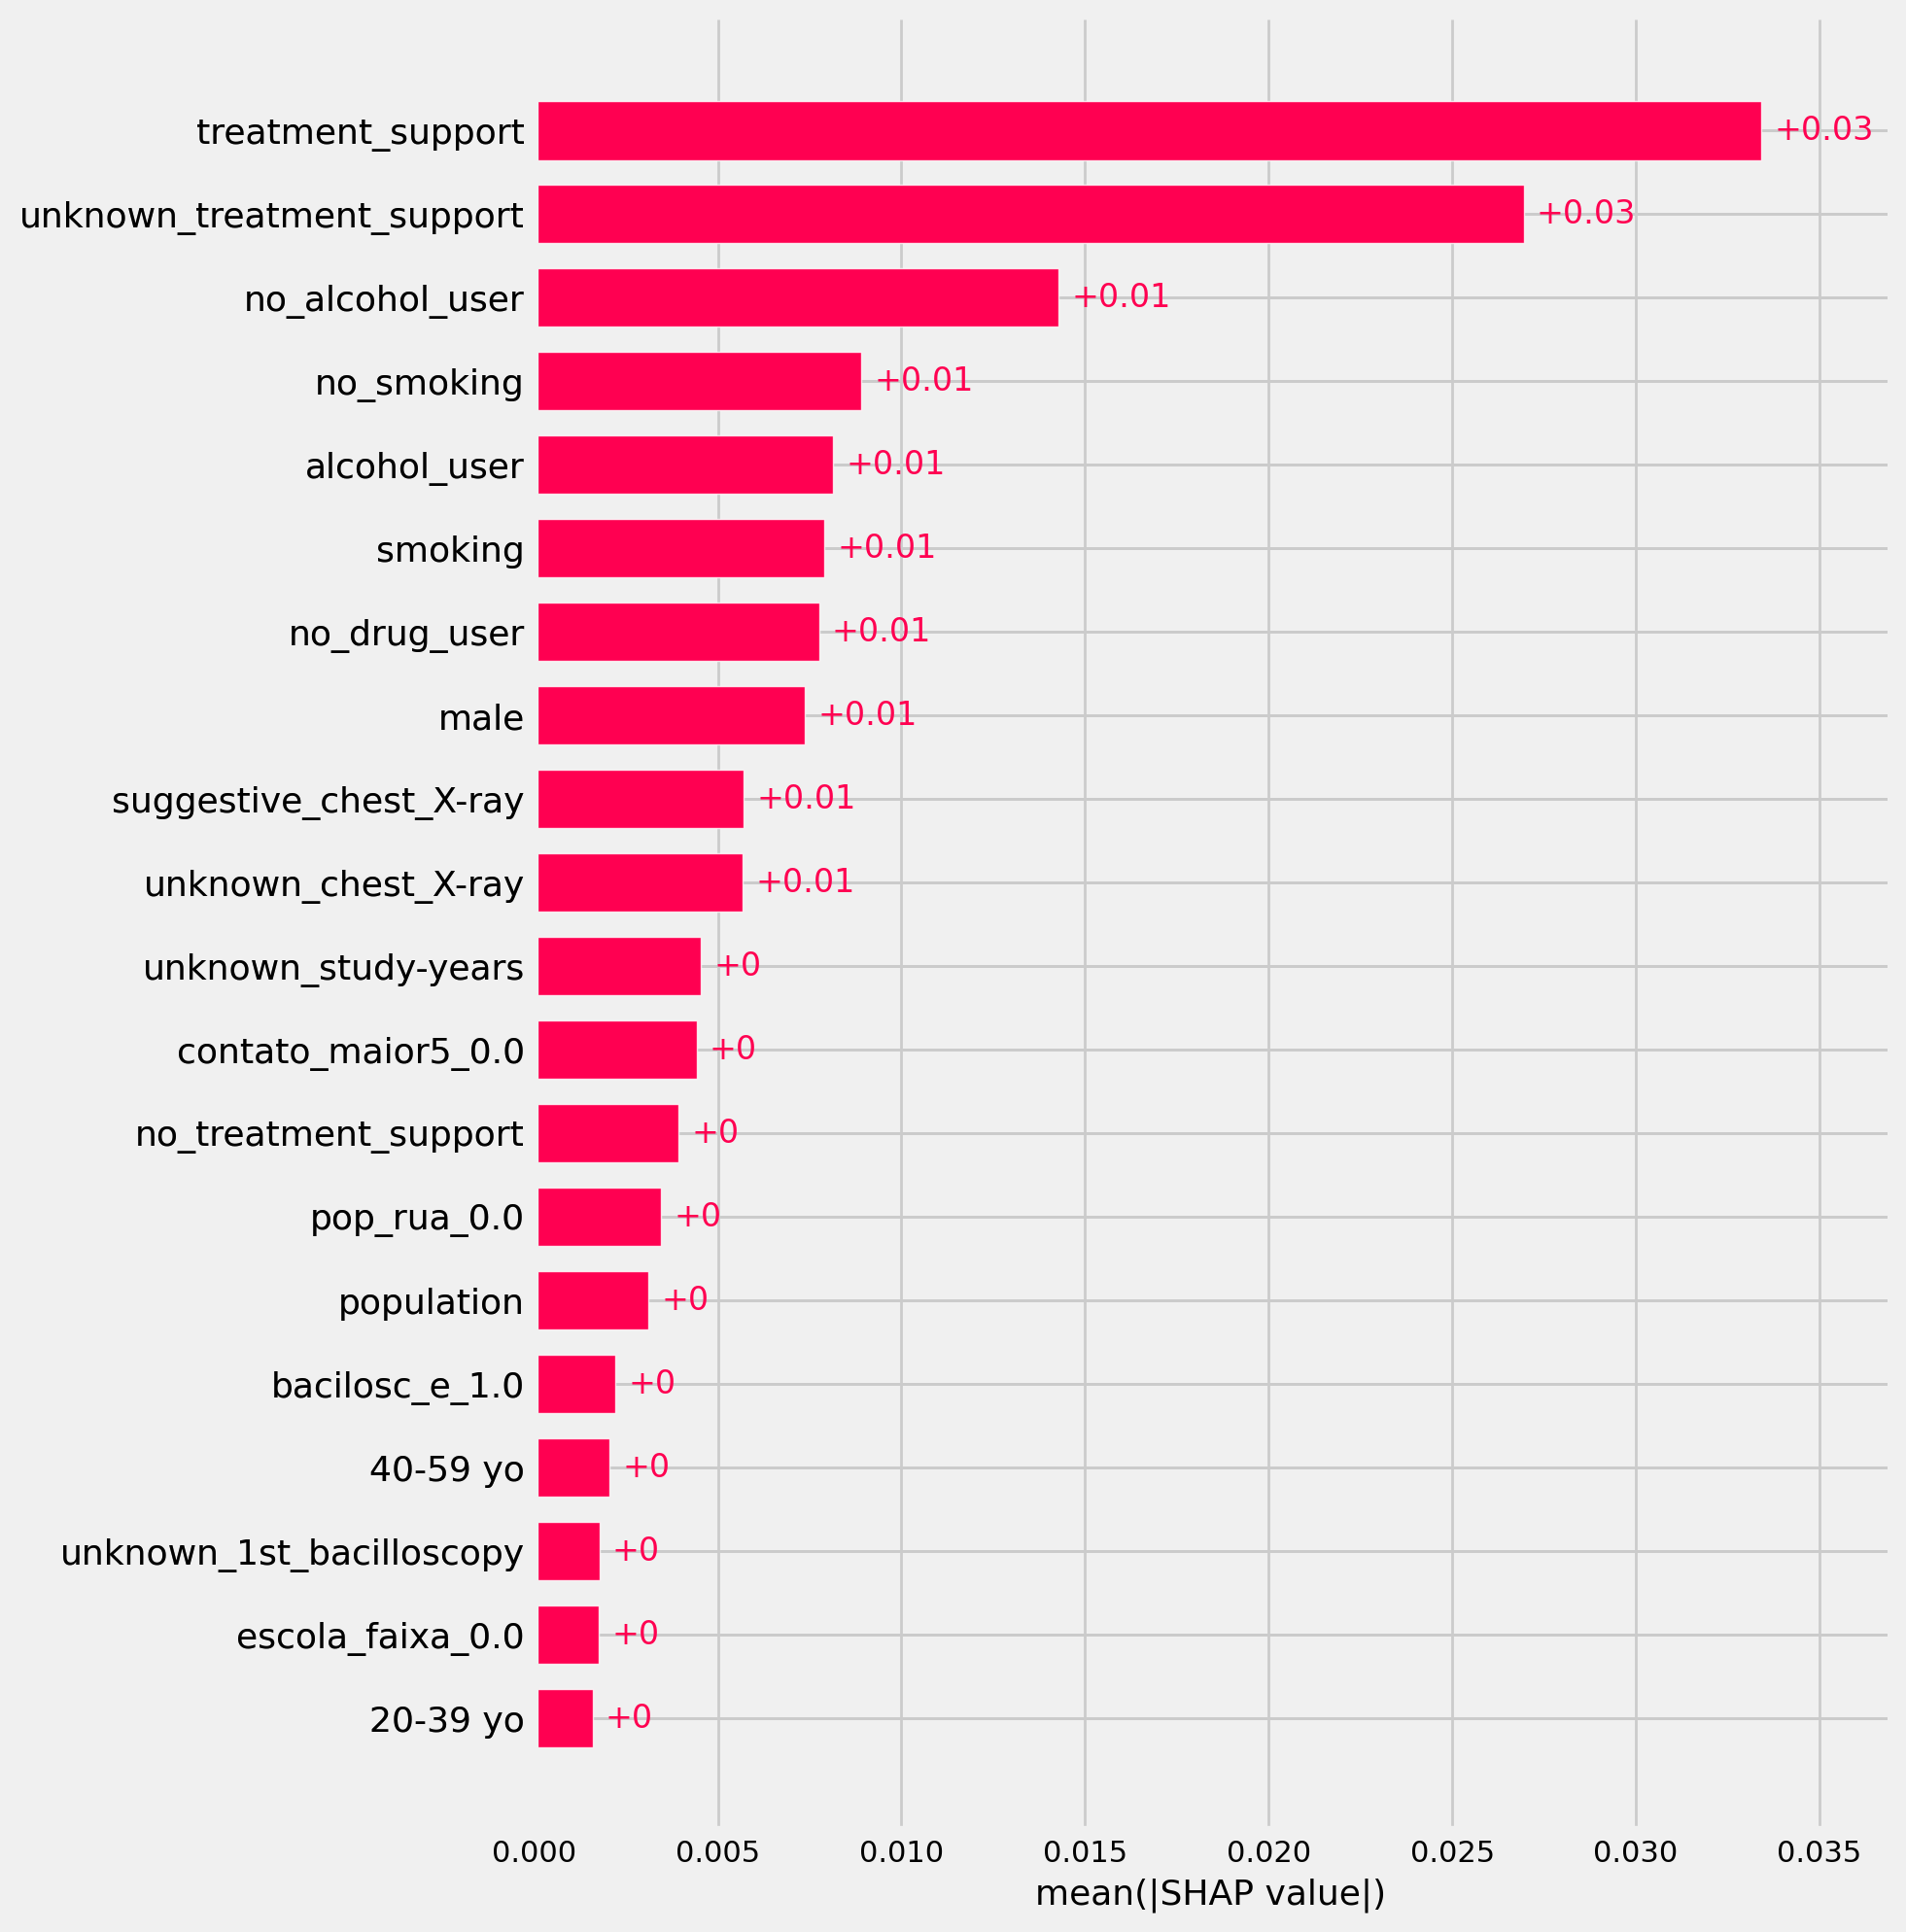

In [94]:
import shap
import matplotlib.pyplot as plt

# Re-criação do Explainer e SHAP Values para garantir consistência
explainer = shap.TreeExplainer(rf_novo)
shap_values = explainer(X_test_novo)

# Gera uma nova lista de nomes de features renomeados
new_feature_names = [
    colunas_renomeadas.get(name, name) for name in shap_values.feature_names
]

# Atribui os nomes renomeados diretamente ao objeto shap_values
shap_values.feature_names = new_feature_names

# Gera o gráfico de barras (versão Matplotlib) - especificando a classe 1 (positivo)
shap.plots.bar(shap_values[:, :, 1],  show=False, max_display=None)

# Salva o gráfico como TIFF em alta resolução
plt.savefig("shap_bar_plot.tiff", format="tiff", dpi=300, bbox_inches="tight")

print("Gráfico salvo como 'shap_bar_plot.tiff' (Matplotlib, 300 DPI)")

## Summary Plot
→ Principal gráfico do SHAP. Sua interpretação mostra:
- Cada ponto é uma amostra
- A cor representa o valor da variável (valores baixos são azuis e valores altos são vermelho)
- Pela posição é possível identificar o quanto cada feature influencia no aumento ou diminuição do desfecho

Variable Importance Plot - Global Interpretation


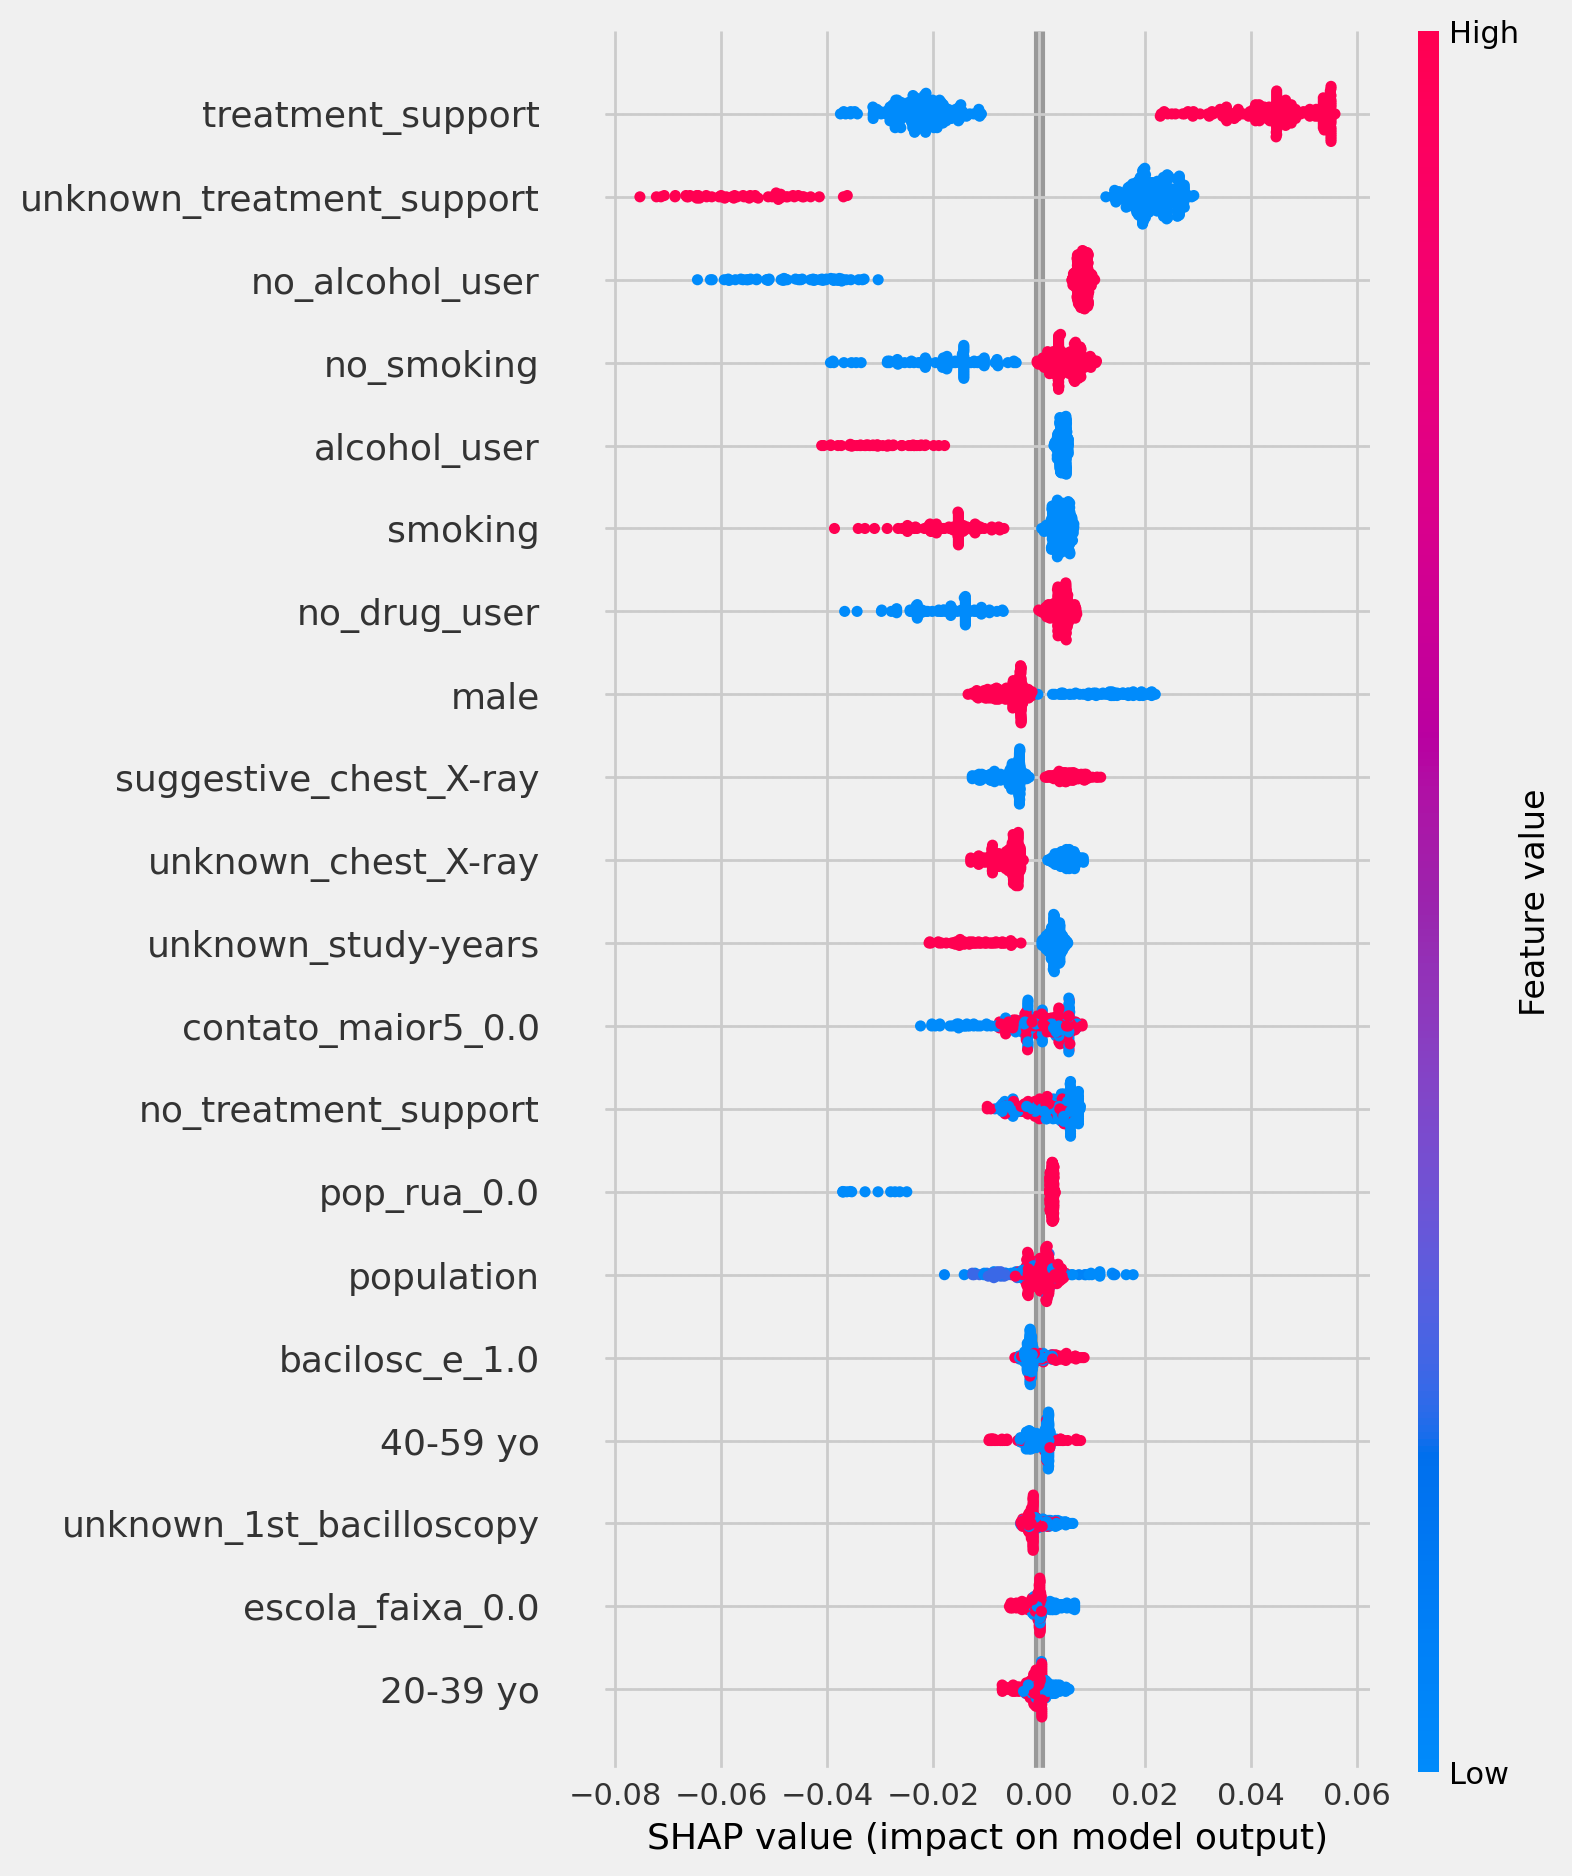

Gráfico salvo como 'shap_summary_plot.tiff' com 300 DPI


<Figure size 1000x500 with 0 Axes>

In [96]:
import shap
import matplotlib.pyplot as plt

# Dicionário com os nomes antigos e os novos nomes
colunas_renomeadas = {
    'bacilosc_e_9.0': 'unknown_1st_bacilloscopy',
    'bacilosc_2_9.0': 'unknown_2nd_bacilloscopy',
    'bacilosc_4_9.0': 'unknown_4th_bacilloscopy',
    'bacilosc_2_0.0': 'negative_2nd_bacilloscopy',
    'bacilosc_4_0.0': 'negative_4th_bacilloscopy',
    'bacilosc_e_0.0': 'negative_baseline_bacilloscopy',
    'bacilosc_4_1.0': 'positive_4th_bacilloscopy',
    'cultura_es_0.0': 'negative_sputum_culture',
    'cultura_es_1.0': 'positive_sputum_culture',
    'cultura_es_9.0': 'unknown_sputum_culture',
    'cs_sexo_1': 'male',
    'escola_faixa_1.0': 'study-years_>5',
    'escola_faixa_9.0': 'unknown_study-years',
    'faixa_etaria2_0.0': '0-19 yo',
    'faixa_etaria2_1.0': '20-39 yo',
    'faixa_etaria2_2.0': '40-59 yo',
    'faixa_etaria2_3.0': '60+ yo',
    'faixa_etaria2_9.0': 'unknown_age',
    'agravdroga_1.0': 'drug_user',
    'agravdroga_0.0': 'no_drug_user',
    'agravdroga_9.0': 'unknown_drug_user',
    'agravalcoo_1.0': 'alcohol_user',
    'agravalcoo_0.0': 'no_alcohol_user',
    'agravalcoo_9.0': 'unknown_alcohol_user',
    'cs_raca_1.0': 'white',
    'cs_raca_2.0': 'black',
    'tratsup_at_1.0': 'treatment_support',
    'tratsup_at_0.0': 'no_treatment_support',
    'tratsup_at_9.0': 'unknown_treatment_support',
    'pop_rua_1.0': 'homeless',
    'pop_liber_1.0': 'incarcerated',
    'pop': 'population',
    'agravdiabe_1.0': 'diabetes',
    'agravdiabe_0.0': 'no_diabetes',
    'agravdoenca_1.0': 'other_diseases',
    'agravtabac_1.0': 'smoking',
    'agravtabac_0.0': 'no_smoking',
    'agravdoenca_0.0': 'no_other_diseases',
    'agravtabac_9.0': 'unknown_smoking',
    'agravdoenc_1.0':'other_diseases',
    'agravdoenc_0.0': 'no_other_diseases',
    'agravdoenc_9.0': 'unknown_other_diseases',
    'agravdiabe_9.0': 'unknown_diabetes',
    'raiox_tora_1.0': 'suggestive_chest_X-ray',
    'raiox__tora_0.0': 'normal_chest_X-ray',
    'raiox_tora_9.0': 'unknown_chest_X-ray',
    'tempo_diag_trat_14_0.0': 'no_delay_treatment',
    'tempo_diag_trat_14_1.0': 'delay_treatment',
    'benef_gov_0.0': 'no_financial_support',
    'benef_gov_1.0': 'financial_support'
}

# Renomear colunas para usar no gráfico SHAP
X_test_shap = X_test_novo.rename(columns=colunas_renomeadas)

# Inicializar SHAP
shap.initjs()

# Criar o explainer
explainer = shap.TreeExplainer(rf_novo)

# Calcular valores SHAP
shap_values = explainer.shap_values(X_test_novo)

# Selecionar valores SHAP da classe positiva
shap_values_class1 = shap_values[:, :, 1]

# Plotar gráfico com os nomes atualizados
print("Variable Importance Plot - Global Interpretation")
figure = plt.figure()
shap.summary_plot(shap_values_class1, X_test_shap)  # ← Corrigido aqui!

# Salvar como .tiff com 300 dpi
plt.savefig('shap_summary_plot.tiff', format='tiff', dpi=300, bbox_inches='tight')
print("Gráfico salvo como 'shap_summary_plot.tiff' com 300 DPI")

## Plot Individual
→ É possível identificar o processo de decisão do modelo a nível de observação, tanto com o force plot quanto com o waterfall plot

→ Os gráficos mostram como cada variável puxa a previsão de um modelo para cima ou para baixo em relação ao valor esperado (média).
- O valor esperado (baseline) é a previsão média do modelo para todos os dados.
- Cada variável empurra a previsão para mais perto de um resultado positivo ou negativo.
- Visualmente, setas vermelhas empurram a previsão para cima (maior probabilidade do evento), e setas azuis empurram a previsão para baixo (menor probabilidade do evento).

In [97]:
df_predict= pd.DataFrame(data={"prob_desfecho": rf_novo.predict_proba(X_test_novo)[:,1],
                         "y_test":y_test})
display(df_predict)

,prob_desfecho,y_test
0,0.766325,0
1,0.620193,0
2,0.868021,1
3,0.826314,1
4,0.953570,1
...,...,...
350,0.896494,0
351,0.843900,1
352,0.941891,1
353,0.949743,1


In [98]:
df_predict.loc[df_predict.y_test==1].sort_values(by="prob_desfecho",ascending=False)

,prob_desfecho,y_test
139,0.983896,1
58,0.968901,1
129,0.968901,1
162,0.968901,1
260,0.964250,1
...,...,...
149,0.675453,1
225,0.674916,1
190,0.674700,1
296,0.651899,1


In [100]:
#visualizar observacao com valor prob alta
X_test_novo.iloc[260]

,260
agravalcoo_0.0,1.000000
tratsup_at_9.0,0.000000
tratsup_at_1.0,1.000000
agravtabac_0.0,1.000000
agravdroga_0.0,1.000000
cs_sexo_1,1.000000
agravalcoo_1.0,0.000000
agravtabac_1.0,0.000000
tratsup_at_0.0,0.000000
contato_maior5_0.0,0.000000


In [101]:
#Force Plot
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[260,:,1])

In [102]:
#Seleçao_pacientes com valores baixos que evoluiram para a cura
df_predict.loc[df_predict.y_test==1].sort_values(by="prob_desfecho",ascending=False).tail(10)

,prob_desfecho,y_test
285,0.695639,1
181,0.695104,1
354,0.690709,1
85,0.684225,1
243,0.681065,1
149,0.675453,1
225,0.674916,1
190,0.674700,1
296,0.651899,1
116,0.603889,1


In [103]:
X_test_novo.iloc[85] #prob baixo

,85
agravalcoo_0.0,1.000000
tratsup_at_9.0,1.000000
tratsup_at_1.0,0.000000
agravtabac_0.0,0.000000
agravdroga_0.0,0.000000
cs_sexo_1,1.000000
agravalcoo_1.0,0.000000
agravtabac_1.0,1.000000
tratsup_at_0.0,0.000000
contato_maior5_0.0,0.000000


In [104]:
#Force Plot
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[85,:,1])

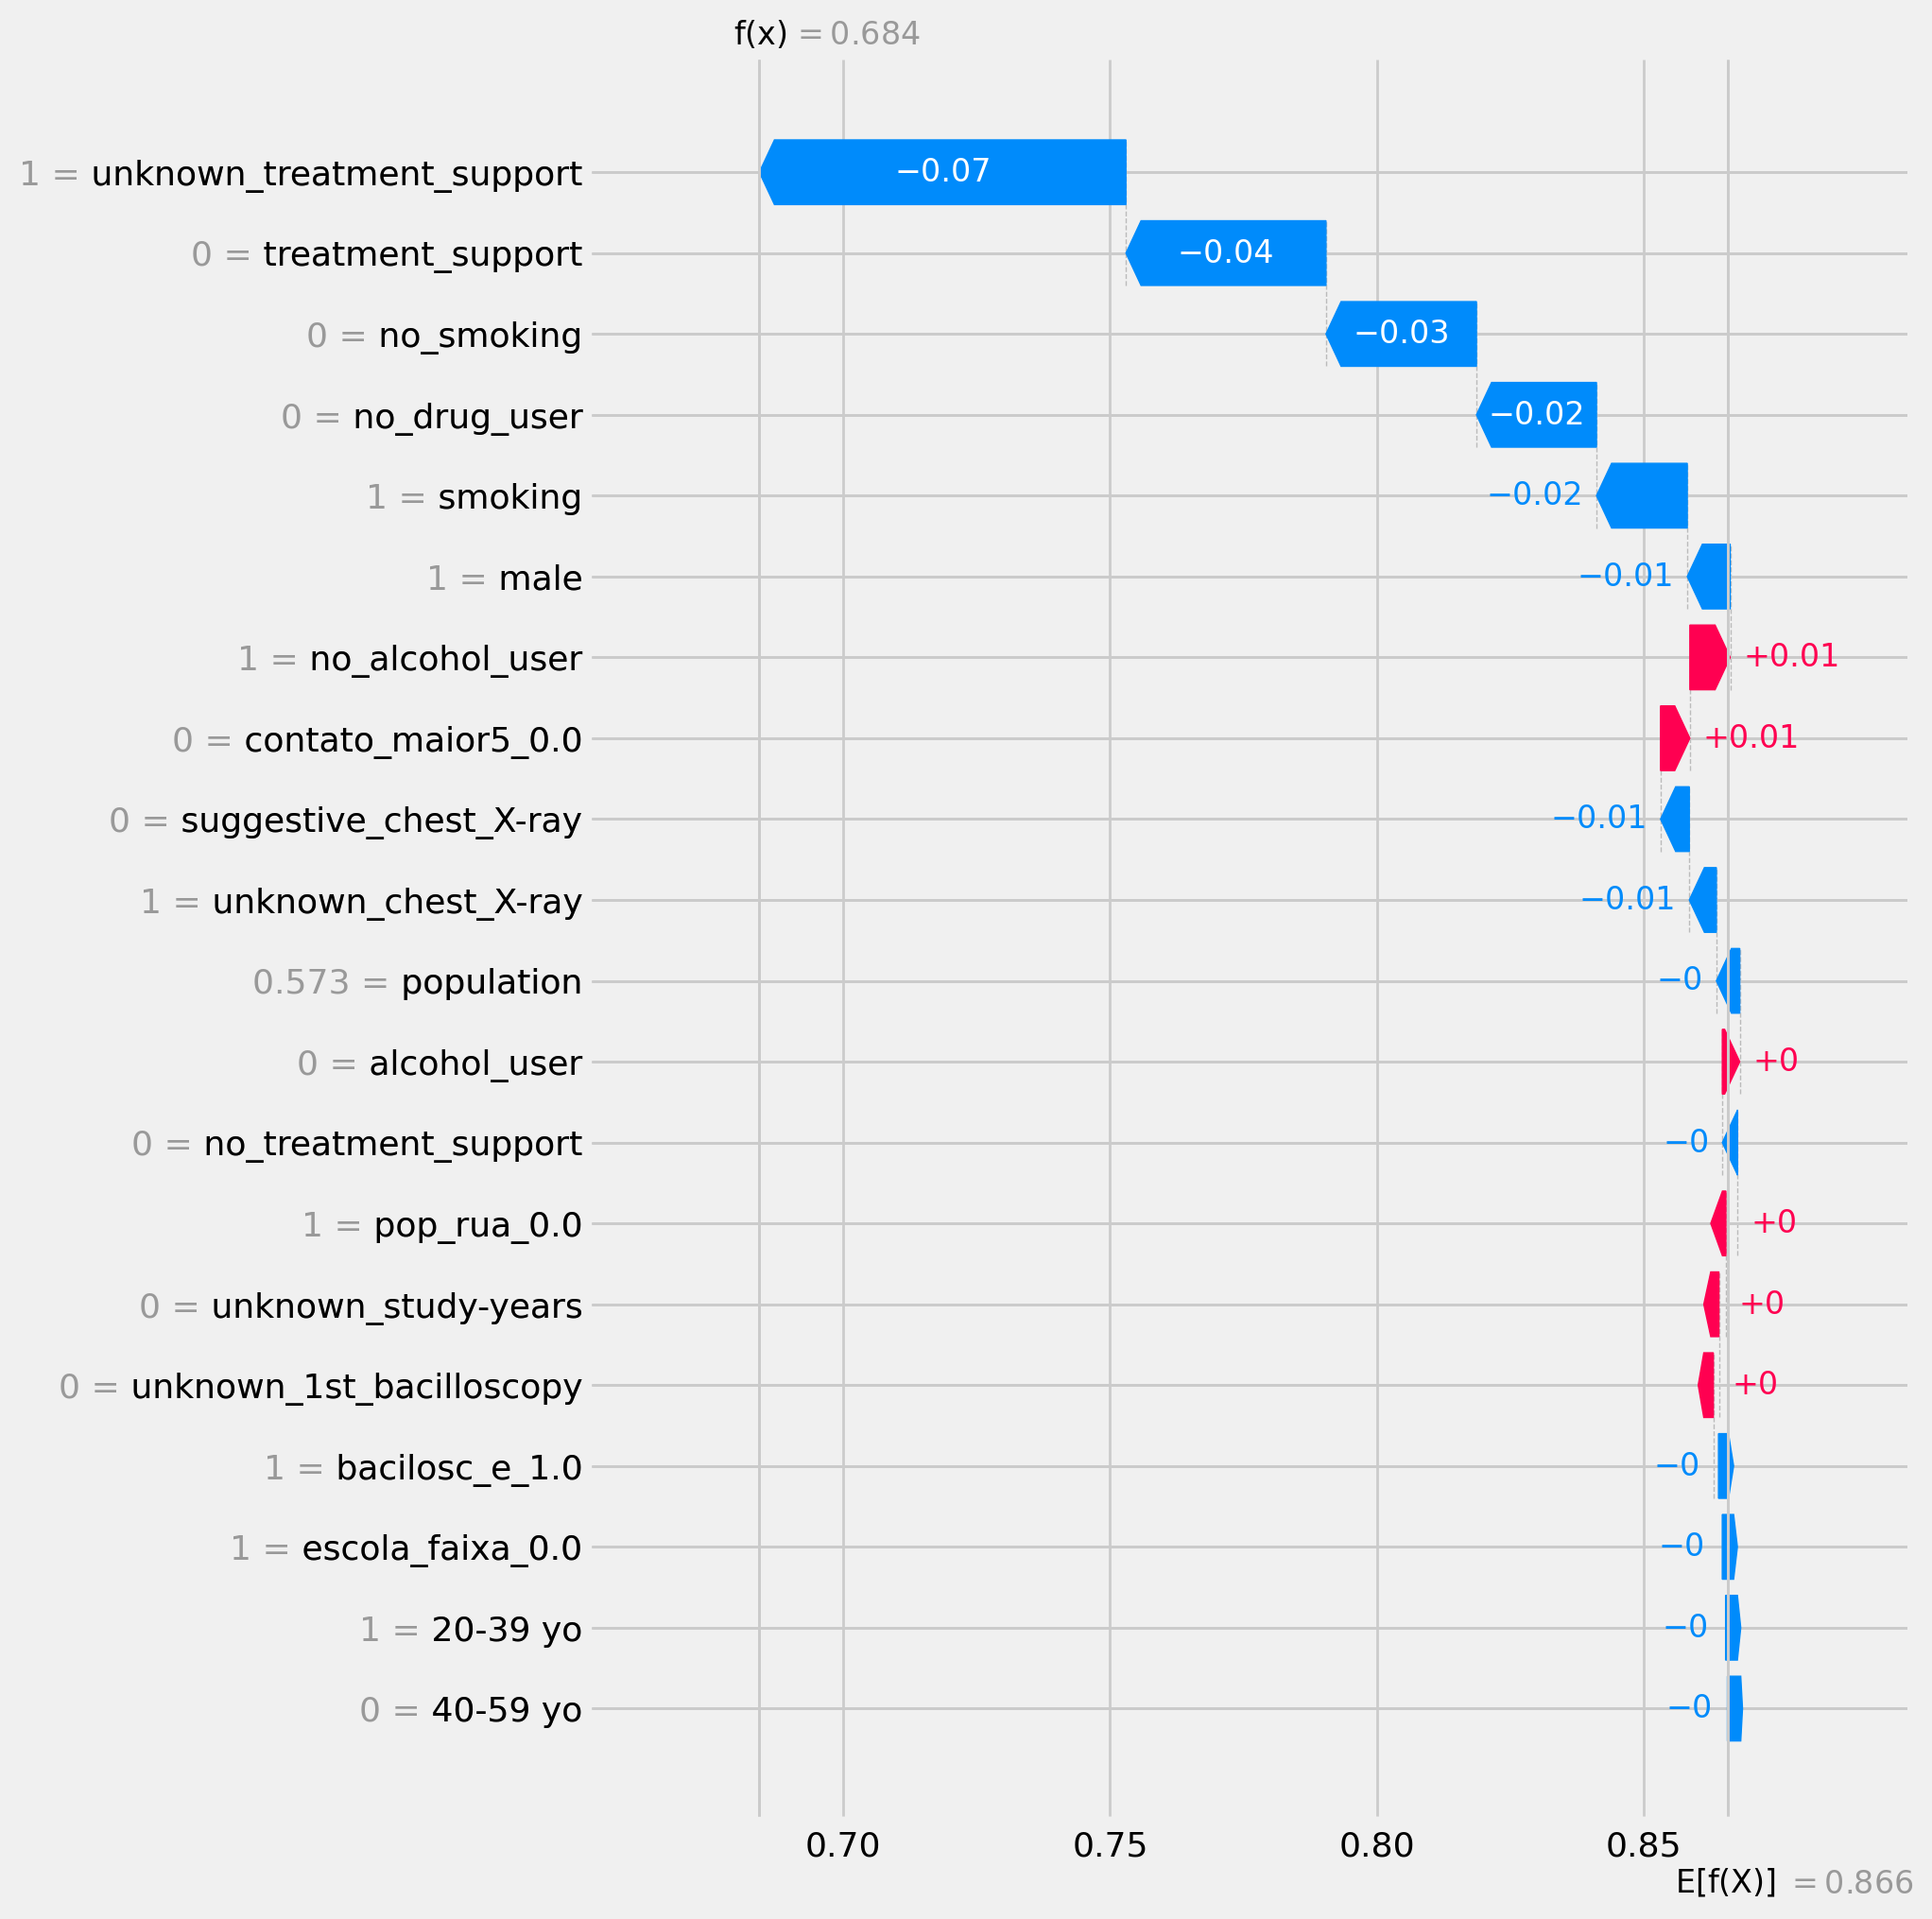

In [105]:
#Waterfall Plot
# Re-create explainer and shap_values to ensure correct type and updated feature names
explainer = shap.TreeExplainer(rf_novo)
shap_values = explainer(X_test_novo)

# Update feature names in the shap_values object
new_feature_names = [
    colunas_renomeadas.get(name, name) for name in X_test_novo.columns
]
shap_values.feature_names = new_feature_names

# Create a single Explanation object for the specific instance and class
single_explanation = shap_values[85, :, 1] # Direct slicing creates a single-output Explanation object

shap.plots.waterfall(single_explanation, max_display=30)

#6- Analise de subgrupo

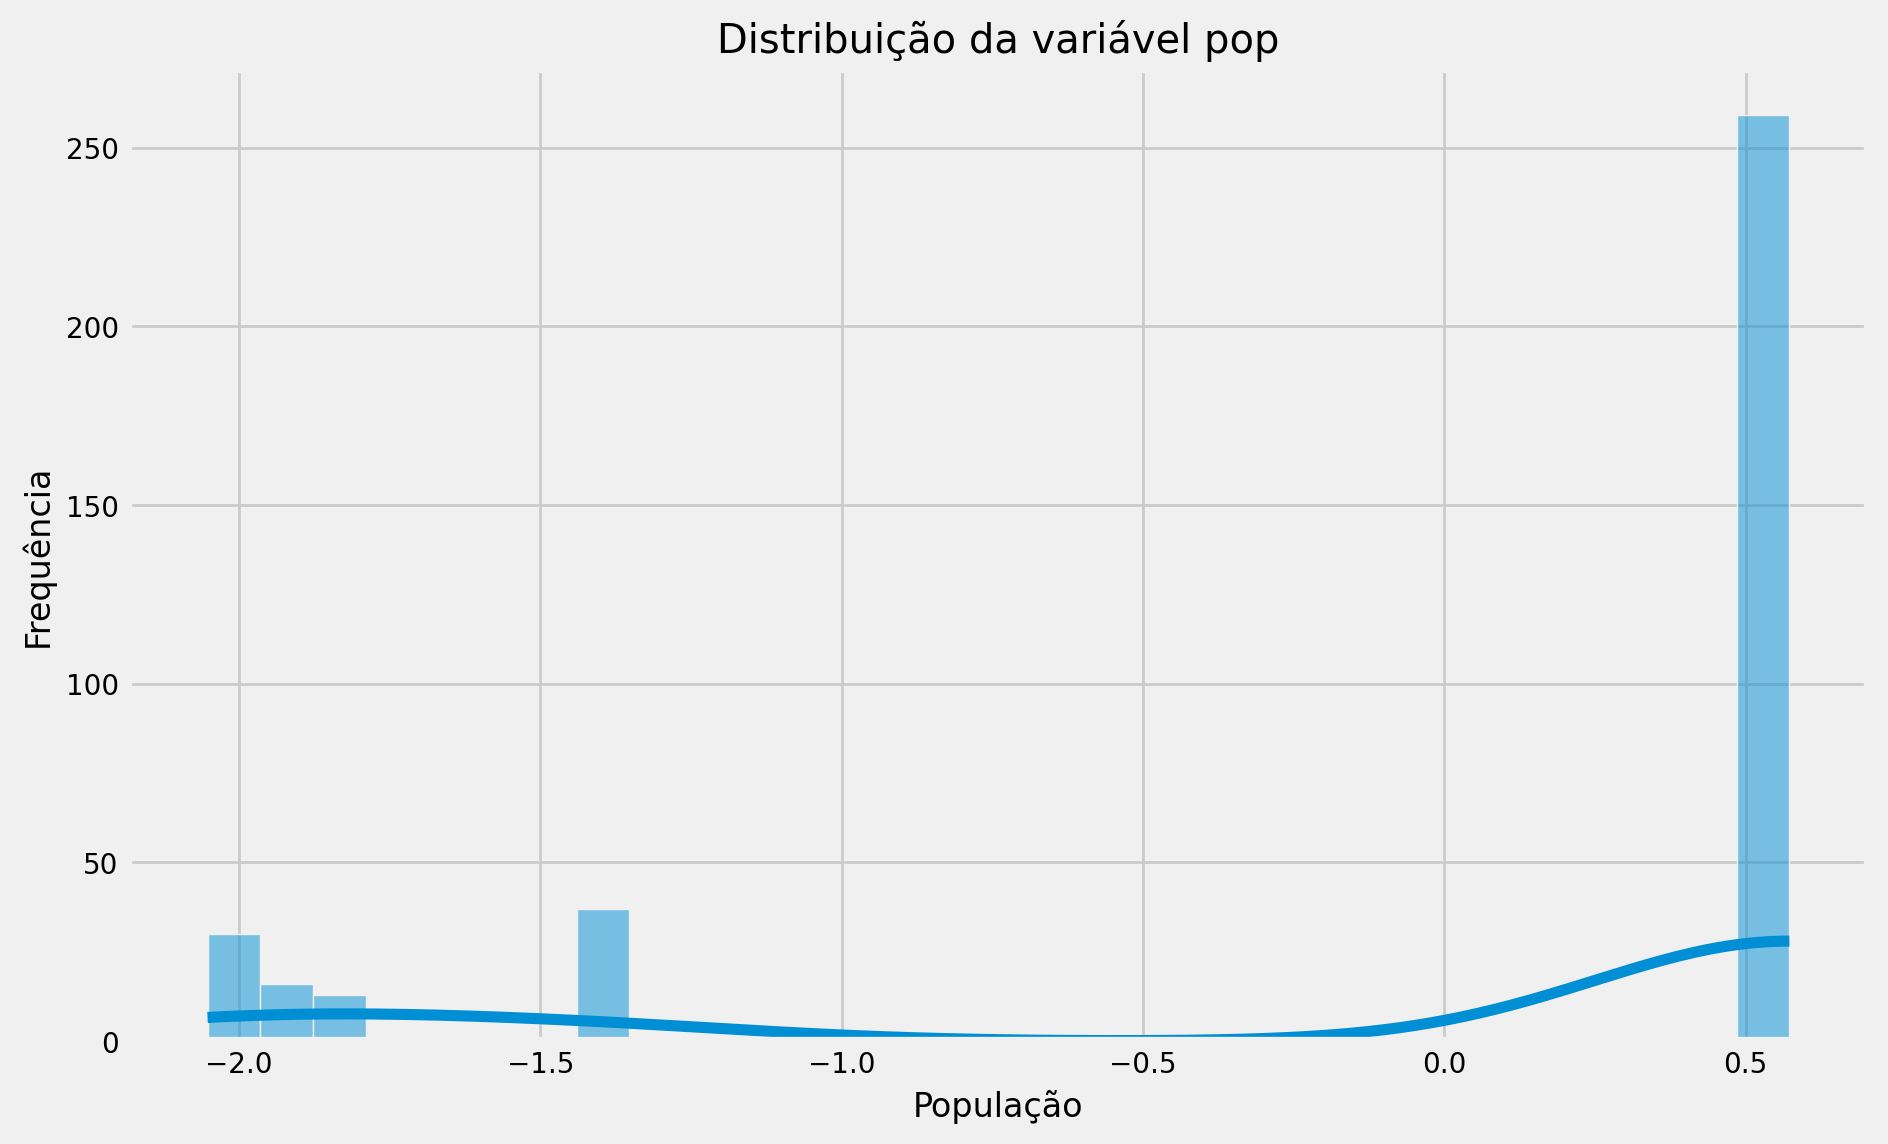

count    355.000000
mean      -0.057268
std        1.044983
min       -2.052044
25%       -1.431558
50%        0.572567
75%        0.572567
max        0.572567
Name: pop, dtype: float64


In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exemplo: o nome da coluna de população
pop_column = 'pop'  # altere se no seu X_test_novo o nome for diferente

# Visualizar distribuição da população
plt.figure(figsize=(10, 6))
sns.histplot(X_test_novo[pop_column], kde=True, bins=30)
plt.title('Distribuição da variável pop')
plt.xlabel('População')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()

# Ver estatísticas básicas
print(X_test_novo[pop_column].describe())


In [107]:
# Ver estatísticas básicas
print(X_test_novo[pop_column].describe())


count    355.000000
mean      -0.057268
std        1.044983
min       -2.052044
25%       -1.431558
50%        0.572567
75%        0.572567
max        0.572567
Name: pop, dtype: float64


In [109]:
print(X_test_novo.shape)
print(y_test.shape)
print(y_prob_rf.shape)
print(y_pred_rf_novo_th.shape)


(355, 20)
(355,)
(355,)
(355,)


In [111]:
# Cria novo DataFrame com as colunas necessárias
df_resultados = X_test_novo.copy()

# Adiciona a coluna pop (se já não estiver presente)
if 'pop' not in df_resultados.columns:
    df_resultados['pop'] = X_test_novo['pop']

# Adiciona os dados de verdadeiros e predições
df_resultados['y_true'] = y_test.values
df_resultados['y_prob'] = y_prob_rf
df_resultados['y_pred'] = y_pred_rf_novo_th


In [112]:
# Criação dos grupos conforme solicitado
bins = [-np.inf,-1.60999, -1.28, np.inf]#
labels = ['< 50000', '50000 a 1000000', '>1000000']

df_resultados['pop_grupo'] = pd.cut(
    df_resultados['pop'],
    bins=bins,
    labels=labels,
    include_lowest=True
)


In [113]:
df_resultados['pop_grupo'].value_counts(dropna=False)

,count
pop_grupo,
>1000000,259
< 50000,59
50000 a 1000000,37


In [114]:
df_resultados['pop_grupo'].value_counts(normalize = True, dropna=False)

,proportion
pop_grupo,
>1000000,0.729577
< 50000,0.166197
50000 a 1000000,0.104225


In [115]:
def calcular_metricas_por_grupo(df, grupo_col='pop_grupo'):
    grupo_metrics = []

    for grupo in df[grupo_col].dropna().unique():
        sub_df = df[df[grupo_col] == grupo]
        y_true = sub_df['y_true']
        y_pred = sub_df['y_pred']
        y_prob = sub_df['y_prob']

        try:
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        except ValueError:
            tn = fp = fn = tp = 0  # caso dê erro por falta de classes

        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        roc_auc = roc_auc_score(y_true, y_prob)
        pr_auc = average_precision_score(y_true, y_prob)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0

        grupo_metrics.append({
            'Grupo': grupo,
            'Accuracy': accuracy,
            'Recall': recall,
            'Specificity': specificity,
            'NPV': npv,
            'Precision': precision,
            'F1': f1,
            'ROC AUC': roc_auc,
            'PR AUC': pr_auc
        })

    return pd.DataFrame(grupo_metrics)


In [116]:
df_metricas_por_pop = calcular_metricas_por_grupo(df_resultados)
print(df_metricas_por_pop)


             Grupo  Accuracy    Recall  Specificity       NPV  Precision  \
0          < 50000  0.762712  0.745098     0.875000  0.350000   0.974359   
1         >1000000  0.698842  0.728972     0.555556  0.301205   0.886364   
2  50000 a 1000000  0.702703  0.696970     0.750000  0.230769   0.958333   

         F1   ROC AUC    PR AUC  
0  0.844444  0.843137  0.975994  
1  0.800000  0.686033  0.893609  
2  0.807018  0.742424  0.965781  


In [117]:
df_resultados.columns

Index(['agravalcoo_0.0', 'tratsup_at_9.0', 'tratsup_at_1.0', 'agravtabac_0.0',
       'agravdroga_0.0', 'cs_sexo_1', 'agravalcoo_1.0', 'agravtabac_1.0',
       'tratsup_at_0.0', 'contato_maior5_0.0', 'raiox_tora_9.0',
       'faixa_etaria2_1.0', 'escola_faixa_0.0', 'bacilosc_e_1.0',
       'raiox_tora_1.0', 'escola_faixa_9.0', 'pop_rua_0.0', 'bacilosc_e_9.0',
       'faixa_etaria2_2.0', 'pop', 'y_true', 'y_prob', 'y_pred', 'pop_grupo'],
      dtype='object')

Sexo

In [118]:
print(df_resultados['cs_sexo_1'].value_counts(dropna=False))


cs_sexo_1
1.0    279
0.0     76
Name: count, dtype: int64


In [119]:
df_metricas_por_raca = calcular_metricas_por_grupo(df_resultados, grupo_col='cs_sexo_1')
print(df_metricas_por_raca)


   Grupo  Accuracy    Recall  Specificity       NPV  Precision        F1  \
0    1.0  0.698925  0.713656     0.634615  0.336735   0.895028  0.794118   
1    0.0  0.750000  0.774648     0.400000  0.111111   0.948276  0.852713   

    ROC AUC    PR AUC  
0  0.716579  0.899753  
1  0.571831  0.951275  


Alcool

In [120]:
print(df_resultados['agravalcoo_1.0'].value_counts(dropna=False))


agravalcoo_1.0
0.0    304
1.0     51
Name: count, dtype: int64


In [121]:
df_metricas_por_alcool = calcular_metricas_por_grupo(df_resultados, grupo_col='agravalcoo_1.0')
print(df_metricas_por_alcool)


   Grupo  Accuracy    Recall  Specificity       NPV  Precision        F1  \
0    1.0  0.313725  0.081081     0.928571  0.276596   0.750000  0.146341   
1    0.0  0.776316  0.819923     0.511628  0.318841   0.910638  0.862903   

    ROC AUC    PR AUC  
0  0.673745  0.821714  
1  0.711886  0.919949  


Tabagismo

In [122]:
print(df_resultados['agravtabac_1.0'].value_counts(dropna=False))


agravtabac_1.0
0.0    254
1.0    101
Name: count, dtype: int64


In [123]:
df_metricas_por_raca = calcular_metricas_por_grupo(df_resultados, grupo_col='agravtabac_1.0')
print(df_metricas_por_raca)


   Grupo  Accuracy    Recall  Specificity    NPV  Precision        F1  \
0    0.0  0.716535  0.742857     0.590909  0.325   0.896552  0.812500   
1    1.0  0.693069  0.693182     0.692308  0.250   0.938462  0.797386   

    ROC AUC    PR AUC  
0  0.706656  0.903451  
1  0.752622  0.951277  


Drogas

In [125]:
print(df_resultados['agravdroga_0.0'].value_counts(dropna=False))


agravdroga_0.0
1.0    258
0.0     97
Name: count, dtype: int64


In [126]:
df_metricas_por_raca = calcular_metricas_por_grupo(df_resultados, grupo_col='agravdroga_0.0')
print(df_metricas_por_raca)


   Grupo  Accuracy    Recall  Specificity       NPV  Precision        F1  \
0    1.0  0.689922  0.715596     0.550000  0.261905   0.896552  0.795918   
1    0.0  0.762887  0.762500     0.764706  0.406250   0.938462  0.841379   

    ROC AUC    PR AUC  
0  0.682282  0.906454  
1  0.788235  0.939909  


In [127]:
df_resultados.columns

Index(['agravalcoo_0.0', 'tratsup_at_9.0', 'tratsup_at_1.0', 'agravtabac_0.0',
       'agravdroga_0.0', 'cs_sexo_1', 'agravalcoo_1.0', 'agravtabac_1.0',
       'tratsup_at_0.0', 'contato_maior5_0.0', 'raiox_tora_9.0',
       'faixa_etaria2_1.0', 'escola_faixa_0.0', 'bacilosc_e_1.0',
       'raiox_tora_1.0', 'escola_faixa_9.0', 'pop_rua_0.0', 'bacilosc_e_9.0',
       'faixa_etaria2_2.0', 'pop', 'y_true', 'y_prob', 'y_pred', 'pop_grupo'],
      dtype='object')

Escolaridade

In [129]:
print(df_resultados['escola_faixa_0.0'].value_counts(dropna=False))


escola_faixa_0.0
1.0    214
0.0    141
Name: count, dtype: int64


In [131]:
df_metricas_por_escola = calcular_metricas_por_grupo(df_resultados, grupo_col='escola_faixa_0.0')
print(df_metricas_por_escola)


   Grupo  Accuracy    Recall  Specificity       NPV  Precision        F1  \
0    1.0  0.691589  0.715054     0.535714  0.220588   0.910959  0.801205   
1    0.0  0.737589  0.750000     0.689655  0.416667   0.903226  0.819512   

    ROC AUC    PR AUC  
0  0.665419  0.911644  
1  0.759236  0.921238  


Pop rua

In [133]:
print(df_resultados['pop_rua_0.0'].value_counts(dropna=False))


pop_rua_0.0
1.0    343
0.0     12
Name: count, dtype: int64


In [134]:
df_metricas_por_raca = calcular_metricas_por_grupo(df_resultados, grupo_col='pop_rua_0.0')
print(df_metricas_por_raca)


   Grupo  Accuracy    Recall  Specificity       NPV  Precision        F1  \
0    1.0  0.711370  0.734483     0.584906  0.287037   0.906383  0.811429   
1    0.0  0.666667  0.500000     1.000000  0.500000   1.000000  0.666667   

   ROC AUC    PR AUC  
0  0.70836  0.914456  
1  0.71875  0.876326  


In [135]:
df_resultados.columns

Index(['agravalcoo_0.0', 'tratsup_at_9.0', 'tratsup_at_1.0', 'agravtabac_0.0',
       'agravdroga_0.0', 'cs_sexo_1', 'agravalcoo_1.0', 'agravtabac_1.0',
       'tratsup_at_0.0', 'contato_maior5_0.0', 'raiox_tora_9.0',
       'faixa_etaria2_1.0', 'escola_faixa_0.0', 'bacilosc_e_1.0',
       'raiox_tora_1.0', 'escola_faixa_9.0', 'pop_rua_0.0', 'bacilosc_e_9.0',
       'faixa_etaria2_2.0', 'pop', 'y_true', 'y_prob', 'y_pred', 'pop_grupo'],
      dtype='object')

Baciloscopia 2

In [136]:
print(df_resultados['bacilosc_e_1.0'].value_counts(dropna=False))


bacilosc_e_1.0
0.0    253
1.0    102
Name: count, dtype: int64


In [137]:
df_metricas_por_raca = calcular_metricas_por_grupo(df_resultados, grupo_col='bacilosc_e_1.0')
print(df_metricas_por_raca)


   Grupo  Accuracy    Recall  Specificity       NPV  Precision        F1  \
0    0.0  0.727273  0.753488     0.578947  0.293333   0.910112  0.824427   
1    1.0  0.666667  0.662651     0.684211  0.317073   0.901639  0.763889   

    ROC AUC    PR AUC  
0  0.697552  0.917603  
1  0.740330  0.908253  
